# **Real Estate Market Insights: An exploratory data analysis of Zameen.com listings in Pakistan**
# **DA11-EDA-PROJECT**
# **Submitted by: Muhammad Anas Nasir**

--------

## **1. Problem Statement**
## Business question

The objective of this project is to identify the key factors that influence residential prices in Pakistan using Zameen.com listings.

By analyzing property charactersitics such as location, city, area , property type, and number of bedrooms, investors can make more informed real estate investment decisions.

------

## **2. Data understanding & Preprocessing**

------

#### Load libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from fuzzywuzzy import process

#### load data

In [6]:
cols = [
    'City',
    'Location',
    'Price',
    'Type',
    'Area',
    'Purpose',
    'Bedrooms',
    'Bathrooms',
    'Kitchens',
    'Description'
]

df = pd.read_csv(
    "scrapped_zameen_data.csv",
    usecols=cols
)

#### basic information

In [11]:
df.head()

,City,Type,Area,Price,Purpose,Location,Description,Bedrooms,Bathrooms,Kitchens
0,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,2,2,NaN
1,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,2,3,1.0
2,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,1,2,NaN
3,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,1,2,4.0
4,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,2,2,NaN


In [12]:
df.shape

(18255, 10)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18255 entries, 0 to 18254
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         18255 non-null  object 
 1   Type         18239 non-null  object 
 2   Area         18239 non-null  object 
 3   Price        18239 non-null  object 
 4   Purpose      18239 non-null  object 
 5   Location     18239 non-null  object 
 6   Description  14893 non-null  object 
 7   Bedrooms     18239 non-null  object 
 8   Bathrooms    18239 non-null  object 
 9   Kitchens     13256 non-null  float64
dtypes: float64(1), object(9)
memory usage: 1.4+ MB


In [14]:
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,18255,84,Karachi,1250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,18239,7,House,13386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,18239,468,5 Marla,3528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,18239,1022,PKR\n60 Thousand,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purpose,18239,2,For Sale,11126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,18239,1051,"Bahria Town Rawalpindi, Rawalpindi, Punjab",1884,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,14893,13617,Marriott Estate And Builders Offer a Ideal Hou...,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bedrooms,18239,12,5,4174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bathrooms,18239,10,6,4993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kitchens,13256.0,NaN,NaN,NaN,1.686859,2.022453,1.0,1.0,2.0,2.0,211.0


#### Duplicate records

In [15]:
print("Duplicates:", df.duplicated().sum())

Duplicates 532


In [20]:
df = df.drop_duplicates()

## **3. Missing Values Treatment**
----

#### Missing values count

In [22]:
df.isnull().sum()

City              0
Type              0
Area              8
Price             8
Purpose           0
Location          0
Description    3148
Bedrooms          8
Bathrooms         8
Kitchens       4883
dtype: int64

#### Missing value percentage

In [24]:
(df.isnull().sum()/len(df))*100

City            0.000000
Type            0.000000
Area            0.045139
Price           0.045139
Purpose         0.000000
Location        0.000000
Description    17.762230
Bedrooms        0.045139
Bathrooms       0.045139
Kitchens       27.551769
dtype: float64

#### Categorical columns

In [25]:
cat_cols = ['City','Location','Type','Purpose']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\manas\AppData\Local\Temp\ipykernel_21508\1704088232.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


# **4. Data Cleaning & Consistency**

Clean Price Column
Current format

PKR
4.75 Crore
 
---------

#### Convert into numeric PKR Values.

In [26]:
def clean_price(price):

    if pd.isna(price):
        return np.nan

    price = str(price).replace("PKR","").replace("\n","").strip()

    if "Crore" in price:
        return float(price.replace("Crore","")) * 10000000

    elif "Lakh" in price:
        return float(price.replace("Lakh","")) * 100000

    else:
        return np.nan

df['Price_PKR'] = df['Price'].apply(clean_price)

#### Convert area to square feet

In [27]:
def convert_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area)

    try:

        value = float(area.split()[0])

        if "Marla" in area:
            return value * 272.25

        elif "Kanal" in area:
            return value * 5445

        elif "Sq. Yd." in area:
            return value * 9

        elif "Sq. Ft." in area:
            return value

    except:
        return np.nan

df['Area_sqft'] = df['Area'].apply(convert_area)

#### Standardize purpose

In [29]:
df['Purpose'] = (
    df['Purpose']
    .str.strip()
    .str.title()
)

#### Standardize city names using fuzzy matching

In [30]:
cities = [
    'Karachi',
    'Lahore',
    'Islamabad',
    'Rawalpindi',
    'Peshawar',
    'Faisalabad'
]

def match_city(city):

    if pd.isna(city):
        return city

    return process.extractOne(city, cities)[0]

df['City'] = df['City'].apply(match_city)

#### Outlier Detection

In [31]:
Q1 = df['Price_PKR'].quantile(0.25)
Q3 = df['Price_PKR'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['Price_PKR'] >= lower) &
    (df['Price_PKR'] <= upper)
]

# **5. Feature engineering**
----

#### Price per square foot


In [32]:
df['Price_per_sqft'] = (
    df['Price_PKR'] /
    df['Area_sqft']
)

#### Property size category

In [33]:
df['Size_Category'] = pd.cut(
    df['Area_sqft'],
    bins=[0,1000,3000,10000,50000],
    labels=['Small','Medium','Large','Luxury']
)

#### Bedroom Density

In [37]:
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'].replace('-', np.nan), errors='coerce')
df['Bedroom_Density'] = df['Bedrooms'] / df['Area_sqft']


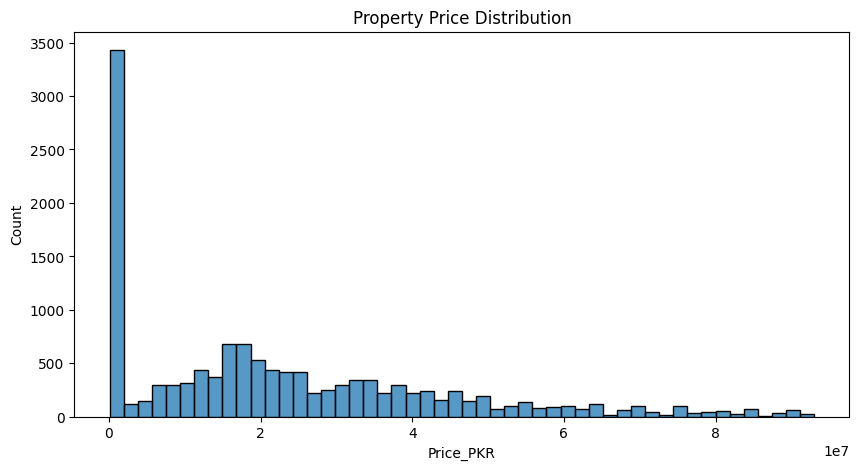

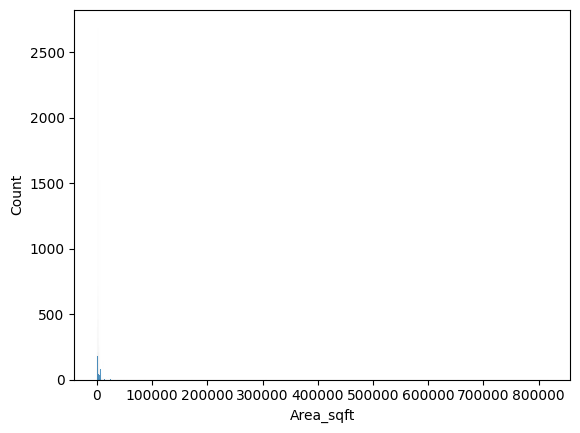

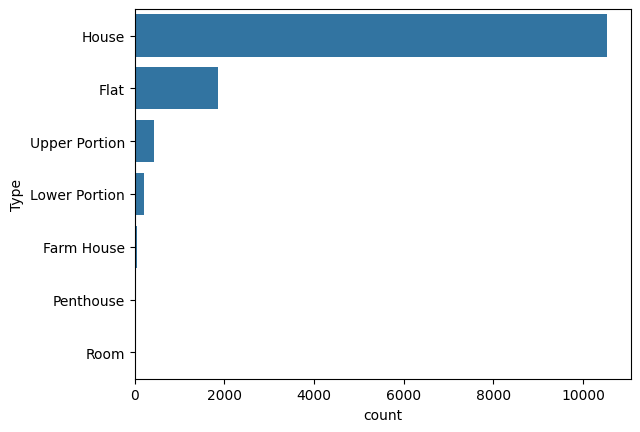

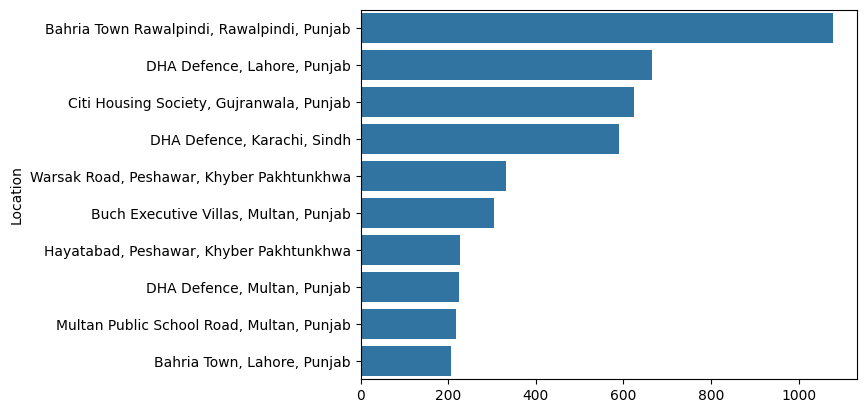

In [39]:
# 6. Univariate Analysis


#Price Distribution


plt.figure(figsize=(10,5))
sns.histplot(df['Price_PKR'], bins=50)
plt.title("Property Price Distribution")
plt.show()

#Area Distribution

sns.histplot(df['Area_sqft'])
plt.show()


#Property Type Count

sns.countplot(
    y=df['Type'],
    order=df['Type'].value_counts().index
)
plt.show()

#Top Locations

top_locations = df['Location'].value_counts().head(10)

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)
plt.show()

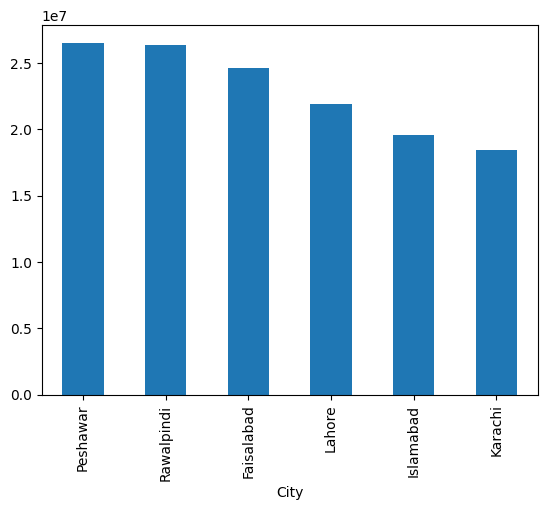

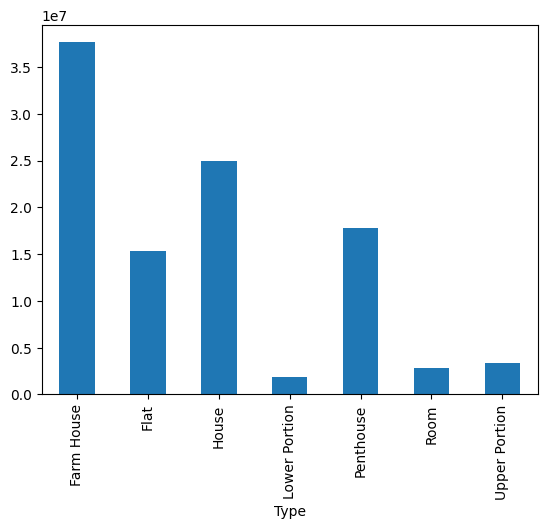

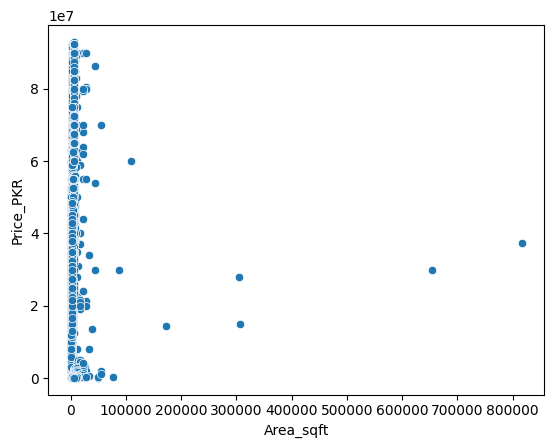

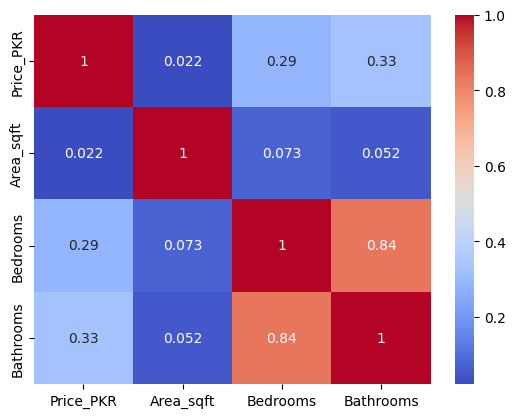

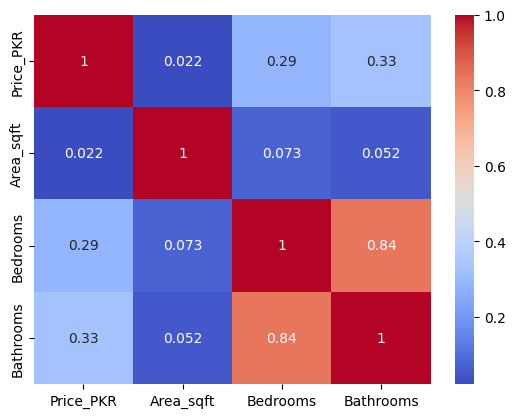

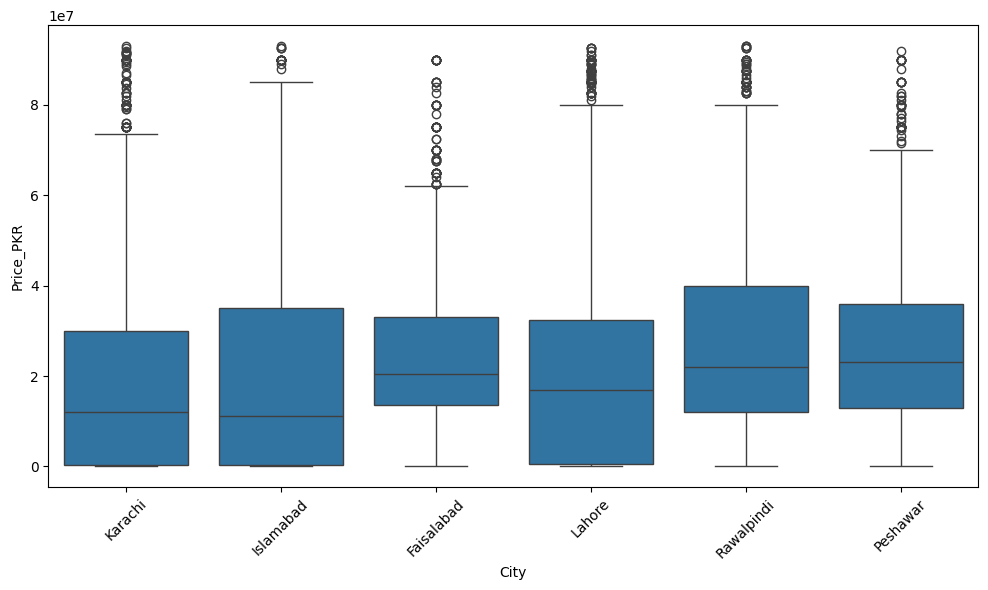

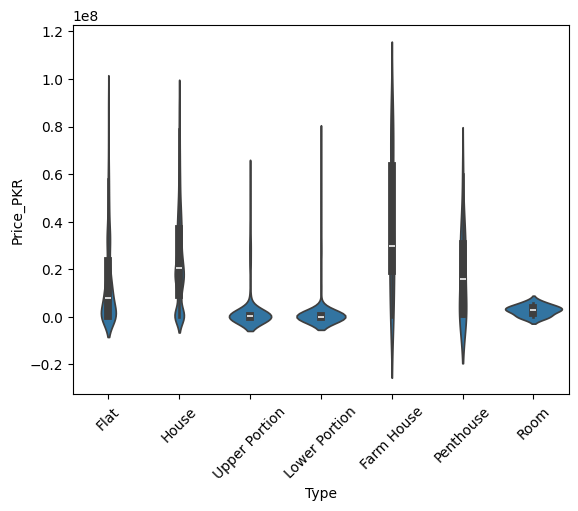

In [46]:
#7. Bivariate Analysis
#Average Price by City

city_price = (
    df.groupby('City')['Price_PKR']
      .mean()
      .sort_values(ascending=False)
)

city_price.plot(kind='bar')
plt.show()

#Average Price by Property Type

type_price = (
    df.groupby('Type')['Price_PKR']
      .mean()
)

type_price.plot(kind='bar')
plt.show()

#Price vs Area

sns.scatterplot(
    data=df,
    x='Area_sqft',
    y='Price_PKR'
)
plt.show()

# correlational heatmap
df['Bathrooms'] = pd.to_numeric(df['Bathrooms'].replace('-', np.nan), errors='coerce')

corr = df[
     ['Price_PKR',
      'Area_sqft',
      'Bedrooms',
      'Bathrooms']
].corr()

sns.heatmap(
     corr,
     annot=True,
     cmap='coolwarm'
)
plt.show()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()


#Boxplot: Price by City

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='City',
    y='Price_PKR'
)

plt.xticks(rotation=45)
plt.show()

#Violin Plot

sns.violinplot(
    data=df,
    x='Type',
    y='Price_PKR'
)

plt.xticks(rotation=45)
plt.show()

---------

# **Conclusion**

The analysis demonstrates that location, city, property type, area size, and bedroom count are the primary drivers of property prices in Pakistan. Price-per-square-foot provides a more reliable valuation metric than total property price. Investors should prioritize high-demand locations and compare properties using standardized area and pricing measures to identify attractive investment opportunities.

---------